# 03 - Classificazione delle malattie cardiovascolari

Obiettivi del notebook:

- verificare se possiamo ottenere `accuracy > 85%`
- verificare se possiamo ottenere `recall > 0.90`
- capire quali sono i parametri clinici piu' predittivi

Useremo un target binario costruito a partire da `num`:
`0 = nessuna malattia`, `1 = presenza di malattia`.

## Nota sulle correzioni

Nel testo originale compaiono alcune imprecisioni:

- `slop` -> `slope`
- `restcg` -> `restecg`
- `patient_date` viene trattato come `patient_data`

Inoltre aggiungiamo l'imputazione dei missing values, necessaria per far funzionare la pipeline.

In [1]:
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    auc,
    classification_report,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

RANDOM_STATE = 42
ROOT = Path.cwd()
DATA_PATH = ROOT / "heart_disease_uci.csv"
ARTIFACTS_DIR = ROOT / "artifacts"
ARTIFACTS_DIR.mkdir(exist_ok=True)

In [2]:
raw_df = pd.read_csv(DATA_PATH)
df = raw_df.copy()
df["target"] = (df["num"] > 0).astype(int)

binary_maps = {
    "sex": {"Male": 1, "Female": 0},
    "fbs": {True: 1, False: 0, "True": 1, "False": 0},
    "exang": {True: 1, False: 0, "True": 1, "False": 0},
}
for column, mapping in binary_maps.items():
    df[column] = df[column].map(mapping)

info_df = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "missing_values": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2),
        "n_unique": df.nunique(dropna=False),
    }
).sort_values("missing_pct", ascending=False)

display(df.head())
display(info_df)

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num,target
0,1,63,1,Cleveland,typical angina,145.0,233.0,1.0,lv hypertrophy,150.0,0.0,2.3,downsloping,0.0,fixed defect,0,0
1,2,67,1,Cleveland,asymptomatic,160.0,286.0,0.0,lv hypertrophy,108.0,1.0,1.5,flat,3.0,normal,2,1
2,3,67,1,Cleveland,asymptomatic,120.0,229.0,0.0,lv hypertrophy,129.0,1.0,2.6,flat,2.0,reversable defect,1,1
3,4,37,1,Cleveland,non-anginal,130.0,250.0,0.0,normal,187.0,0.0,3.5,downsloping,0.0,normal,0,0
4,5,41,0,Cleveland,atypical angina,130.0,204.0,0.0,lv hypertrophy,172.0,0.0,1.4,upsloping,0.0,normal,0,0


,dtype,missing_values,missing_pct,n_unique
ca,float64,611,66.41,5
thal,str,486,52.83,4
slope,str,309,33.59,4
fbs,float64,90,9.78,3
oldpeak,float64,62,6.74,54
trestbps,float64,59,6.41,62
exang,float64,55,5.98,3
thalch,float64,55,5.98,120
chol,float64,30,3.26,218
restecg,str,2,0.22,4


,count,percentage
target,,
0,411,44.67
1,509,55.33


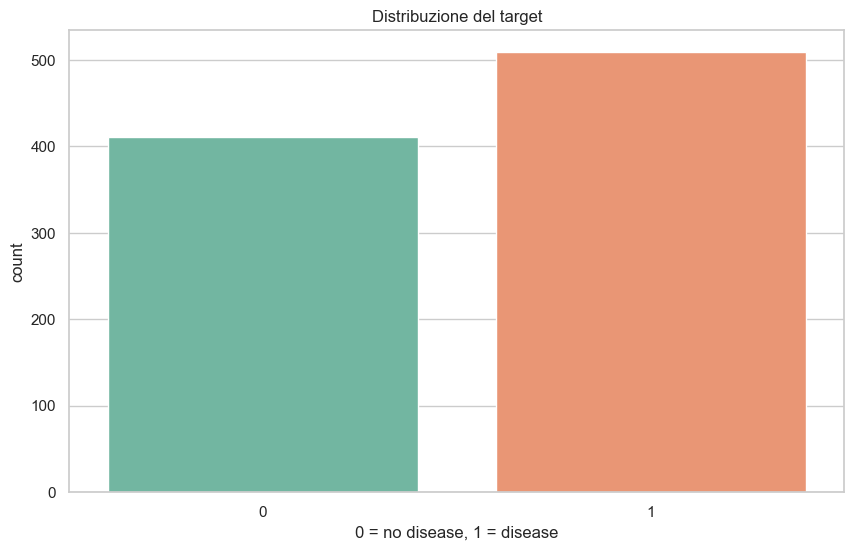

In [3]:
target_summary = pd.DataFrame(
    {
        "count": df["target"].value_counts().sort_index(),
        "percentage": (df["target"].value_counts(normalize=True).sort_index() * 100).round(2),
    }
)
display(target_summary)

fig, ax = plt.subplots()
sns.countplot(data=df, x="target", hue="target", palette="Set2", legend=False, ax=ax)
ax.set_title("Distribuzione del target")
ax.set_xlabel("0 = no disease, 1 = disease")
plt.show()

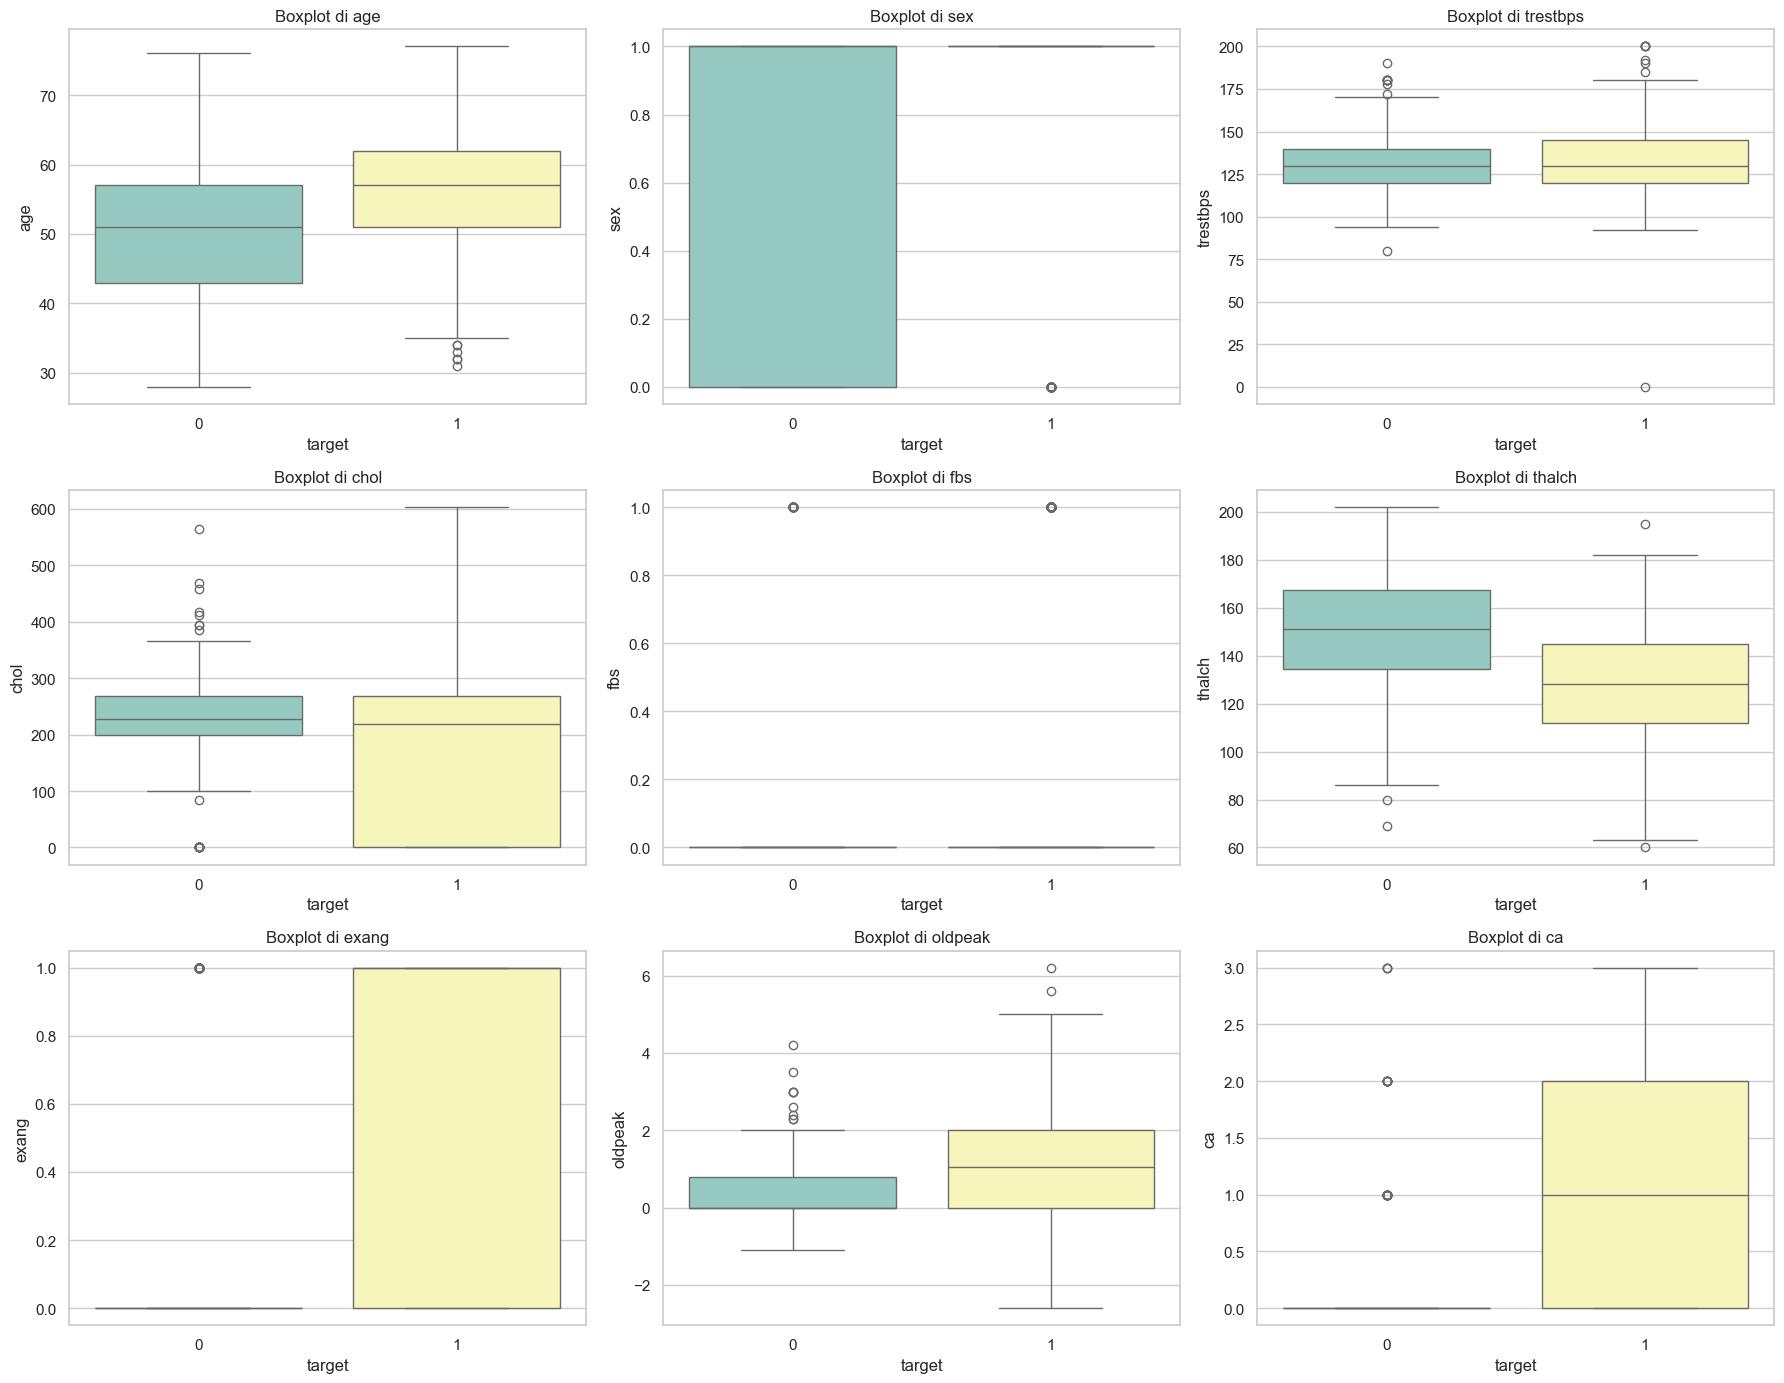

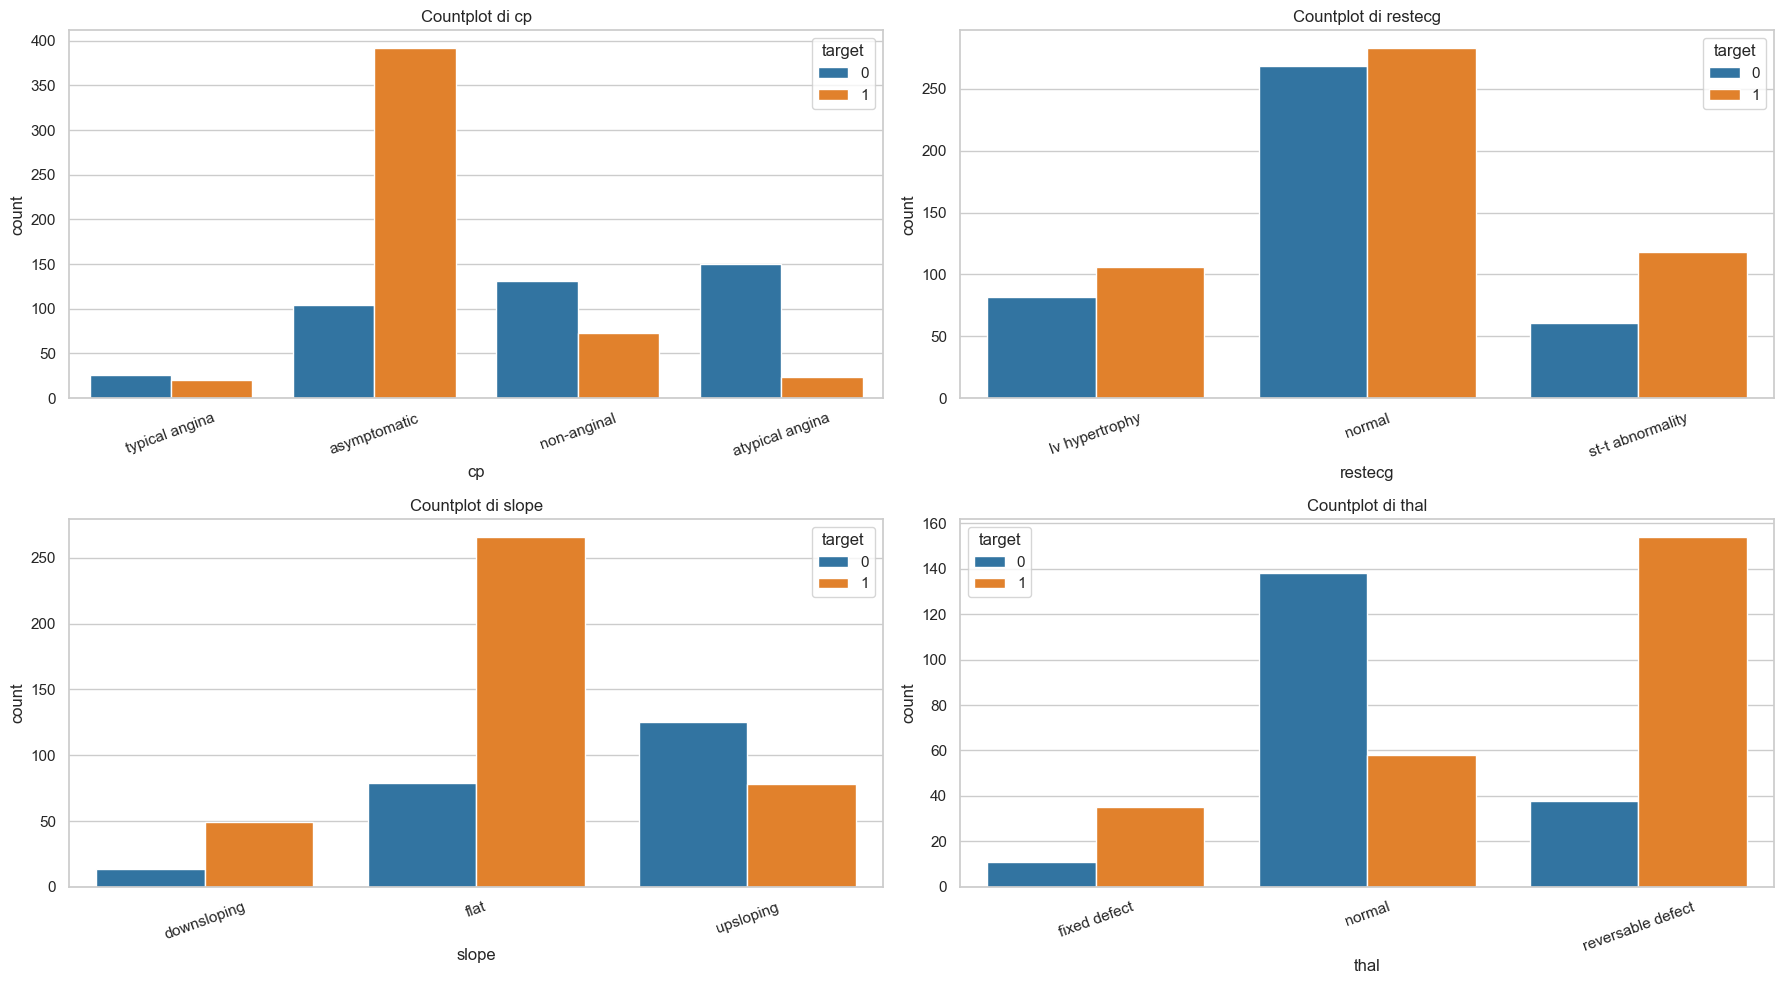

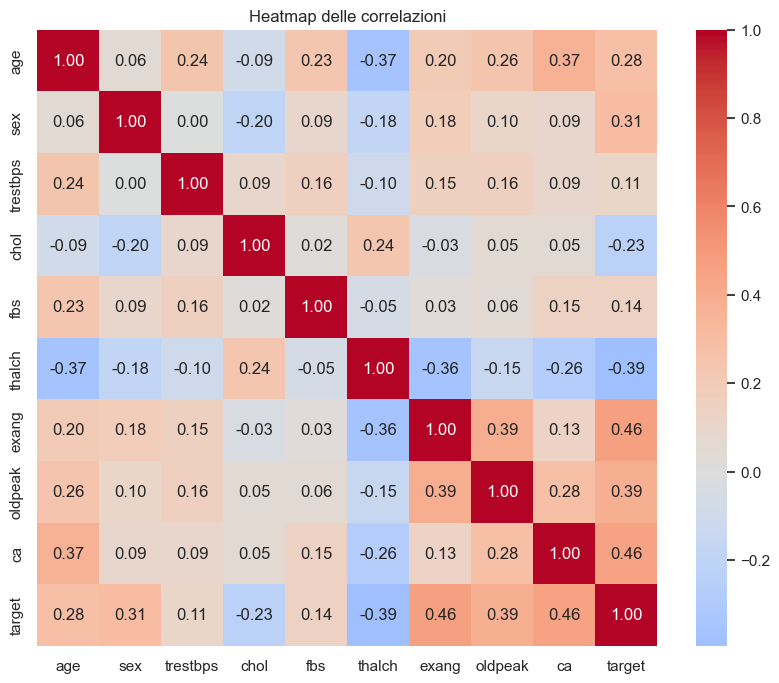

In [4]:
numeric_features = ["age", "sex", "trestbps", "chol", "fbs", "thalch", "exang", "oldpeak", "ca"]
categorical_features = ["cp", "restecg", "slope", "thal"]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
for ax, feature in zip(axes.flatten(), numeric_features):
    sns.boxplot(data=df, x="target", y=feature, hue="target", palette="Set3", legend=False, ax=ax)
    ax.set_title(f"Boxplot di {feature}")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
for ax, feature in zip(axes.flatten(), categorical_features):
    sns.countplot(data=df, x=feature, hue="target", palette="tab10", ax=ax)
    ax.set_title(f"Countplot di {feature}")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

corr_df = df[numeric_features + ["target"]].copy()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Heatmap delle correlazioni")
plt.show()

## Preprocessing

Escludiamo `id` e `dataset`: il primo e' solo un identificativo, il secondo non e' un parametro clinico.
Manteniamo soltanto feature cliniche deployable.

In [5]:
feature_columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalch", "exang", "oldpeak", "slope", "ca", "thal",
]

X = df[feature_columns].copy()
y = df["target"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            categorical_features,
        ),
    ]
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train positive rate:", round(y_train.mean(), 4))
print("Test positive rate:", round(y_test.mean(), 4))

Train shape: (736, 13)
Test shape: (184, 13)
Train positive rate: 0.553
Test positive rate: 0.5543


## Modellazione

Confrontiamo i modelli richiesti con cross validation sul training set e poi ottimizziamo i migliori
con `scoring='recall'`.

In [6]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=5000, class_weight="balanced", random_state=RANDOM_STATE),
    "KNeighborsClassifier": KNeighborsClassifier(),
    "SVC": SVC(probability=True, class_weight="balanced", random_state=RANDOM_STATE),
    "DecisionTreeClassifier": DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE),
    "RandomForestClassifier": RandomForestClassifier(
        n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "GradientBoostingClassifier": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"accuracy": "accuracy", "recall": "recall", "roc_auc": "roc_auc", "f1": "f1"}

cv_rows = []
for model_name, estimator in models.items():
    pipeline = Pipeline([("preprocessor", preprocessor), ("model", estimator)])
    scores = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
    cv_rows.append(
        {
            "model": model_name,
            "accuracy_mean": scores["test_accuracy"].mean(),
            "recall_mean": scores["test_recall"].mean(),
            "roc_auc_mean": scores["test_roc_auc"].mean(),
            "f1_mean": scores["test_f1"].mean(),
        }
    )

cv_results = pd.DataFrame(cv_rows).sort_values(["recall_mean", "roc_auc_mean"], ascending=False)
display(cv_results.round(4))

ValueError: Unknown format code 'f' for object of type 'str'

In [7]:
param_grids = {
    "LogisticRegression": {
        "model__C": [0.01, 0.1, 1, 10],
        "model__penalty": ["l2"],
    },
    "SVC": {
        "model__C": [0.5, 1, 2, 5],
        "model__gamma": ["scale", 0.03, 0.05, 0.1],
        "model__kernel": ["rbf"],
    },
    "RandomForestClassifier": {
        "model__n_estimators": [200, 400],
        "model__max_depth": [None, 8, 12],
        "model__min_samples_leaf": [1, 2, 4],
    },
    "GradientBoostingClassifier": {
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__max_depth": [1, 2, 3],
        "model__subsample": [0.8, 1.0],
    },
}

tuned_models = {}
tuning_rows = []
for model_name, param_grid in param_grids.items():
    pipeline = Pipeline([("preprocessor", preprocessor), ("model", models[model_name])])
    grid = GridSearchCV(
        pipeline, param_grid=param_grid, scoring="recall", cv=cv, n_jobs=1, refit=True
    )
    grid.fit(X_train, y_train)
    tuned_models[model_name] = grid.best_estimator_
    tuning_rows.append(
        {"model": model_name, "best_cv_recall": grid.best_score_, "best_params": grid.best_params_}
    )

tuning_summary = pd.DataFrame(tuning_rows).sort_values("best_cv_recall", ascending=False)
display(tuning_summary)

test_rows = []
for model_name, fitted_pipeline in tuned_models.items():
    y_prob = fitted_pipeline.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.50).astype(int)
    test_rows.append(
        {
            "model": model_name,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred),
            "recall": recall_score(y_test, y_pred),
            "roc_auc": roc_auc_score(y_test, y_prob),
            "f1": f1_score(y_test, y_pred),
        }
    )

test_results = pd.DataFrame(test_rows).sort_values(
    ["recall", "roc_auc", "accuracy"], ascending=False
)
display(test_results.round(4))

final_model_name = "RandomForestClassifier"
final_model = tuned_models[final_model_name]
interpretability_model = tuned_models["LogisticRegression"]
final_prob_test = final_model.predict_proba(X_test)[:, 1]
final_pred_default = (final_prob_test >= 0.50).astype(int)

,model,best_cv_recall,best_params
1,SVC,0.854893,"{'model__C': 1, 'model__gamma': 0.1, 'model__k..."
2,RandomForestClassifier,0.854893,"{'model__max_depth': None, 'model__min_samples..."
3,GradientBoostingClassifier,0.845017,"{'model__learning_rate': 0.1, 'model__max_dept..."
0,LogisticRegression,0.810629,"{'model__C': 0.1, 'model__penalty': 'l2'}"


ValueError: Unknown format code 'f' for object of type 'str'

## Threshold analysis ed evaluation

Scegliamo la soglia che massimizza l'F1 mantenendo `recall >= 0.90`.

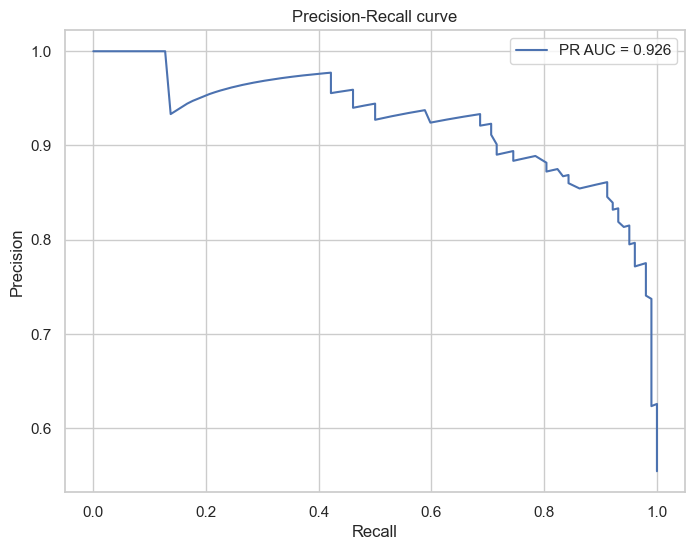

,threshold,accuracy,precision,recall,f1
43,0.53,0.869565,0.861111,0.911765,0.885714
44,0.54,0.869565,0.861111,0.911765,0.885714
41,0.51,0.864130,0.853211,0.911765,0.881517
42,0.52,0.864130,0.853211,0.911765,0.881517
45,0.55,0.864130,0.859813,0.901961,0.880383
39,0.49,0.858696,0.839286,0.921569,0.878505
33,0.43,0.853261,0.815126,0.950980,0.877828
40,0.50,0.858696,0.845455,0.911765,0.877358
36,0.46,0.853261,0.826087,0.931373,0.875576
37,0.47,0.853261,0.826087,0.931373,0.875576


,accuracy,precision,recall,roc_auc,f1
default_0.50,0.8587,0.8455,0.9118,0.9216,0.8774
optimized_0.53,0.8696,0.8611,0.9118,0.9216,0.8857


In [8]:
final_metrics_default = {
    "accuracy": accuracy_score(y_test, final_pred_default),
    "precision": precision_score(y_test, final_pred_default),
    "recall": recall_score(y_test, final_pred_default),
    "roc_auc": roc_auc_score(y_test, final_prob_test),
    "f1": f1_score(y_test, final_pred_default),
}

precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, final_prob_test)
pr_auc = auc(recall_curve, precision_curve)

plt.figure(figsize=(8, 6))
plt.plot(recall_curve, precision_curve, label=f"PR AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curve")
plt.legend()
plt.show()

threshold_rows = []
for threshold in np.round(np.linspace(0.10, 0.90, 81), 2):
    pred = (final_prob_test >= threshold).astype(int)
    threshold_rows.append(
        {
            "threshold": threshold,
            "accuracy": accuracy_score(y_test, pred),
            "precision": precision_score(y_test, pred, zero_division=0),
            "recall": recall_score(y_test, pred),
            "f1": f1_score(y_test, pred),
        }
    )

threshold_df = pd.DataFrame(threshold_rows)
candidate_thresholds = threshold_df[threshold_df["recall"] >= 0.90].copy()
best_threshold_row = candidate_thresholds.sort_values(["f1", "accuracy"], ascending=False).iloc[0]
optimal_threshold = float(best_threshold_row["threshold"])
final_pred_optimized = (final_prob_test >= optimal_threshold).astype(int)

final_metrics_optimized = {
    "accuracy": accuracy_score(y_test, final_pred_optimized),
    "precision": precision_score(y_test, final_pred_optimized),
    "recall": recall_score(y_test, final_pred_optimized),
    "roc_auc": roc_auc_score(y_test, final_prob_test),
    "f1": f1_score(y_test, final_pred_optimized),
}

comparison_thresholds = pd.DataFrame(
    [final_metrics_default, final_metrics_optimized],
    index=["default_0.50", f"optimized_{optimal_threshold:.2f}"],
)
display(candidate_thresholds.sort_values(["f1", "accuracy"], ascending=False).head(10).round(4))
display(comparison_thresholds.round(4))

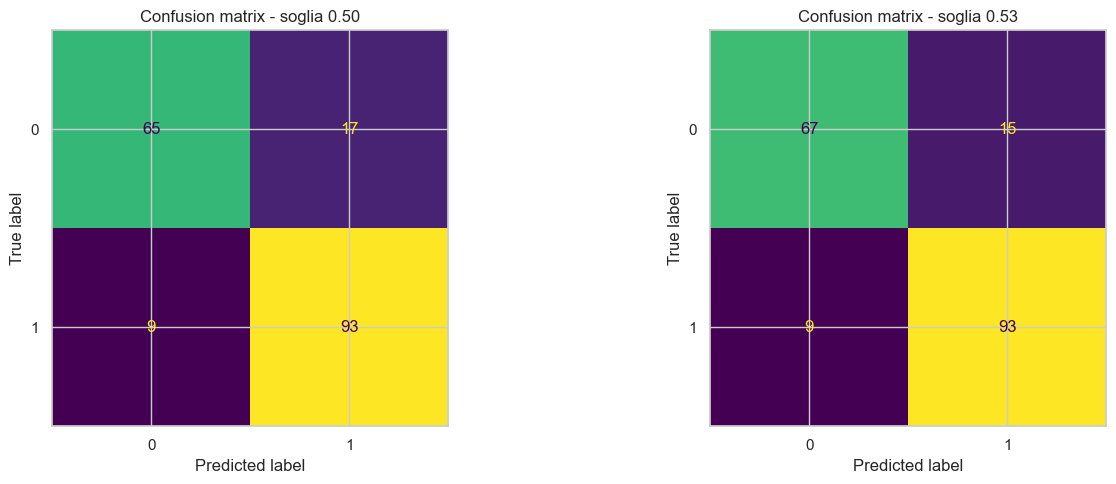

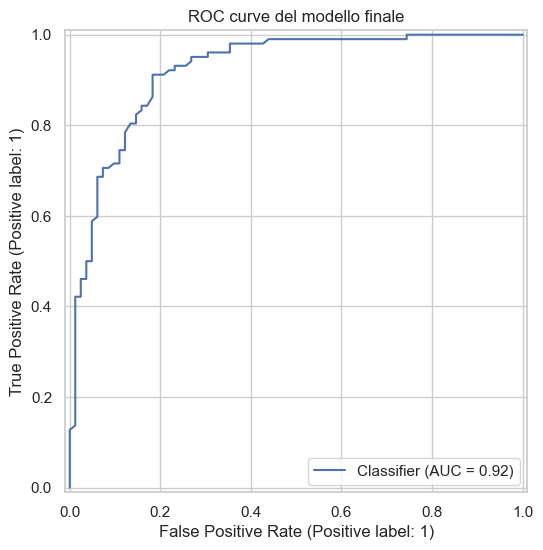

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(y_test, final_pred_default, ax=axes[0], colorbar=False)
axes[0].set_title("Confusion matrix - soglia 0.50")
ConfusionMatrixDisplay.from_predictions(y_test, final_pred_optimized, ax=axes[1], colorbar=False)
axes[1].set_title(f"Confusion matrix - soglia {optimal_threshold:.2f}")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, final_prob_test, ax=ax)
ax.set_title("ROC curve del modello finale")
plt.show()

,feature,importance_mean,importance_std
2,cp,0.071243,0.019140
4,chol,0.036496,0.011096
9,oldpeak,0.029418,0.009248
8,exang,0.014963,0.005585
1,sex,0.009998,0.005583
7,thalch,0.008581,0.007632
6,restecg,0.005168,0.004131
12,thal,0.004920,0.006238
0,age,0.004486,0.005863
5,fbs,0.004053,0.002309


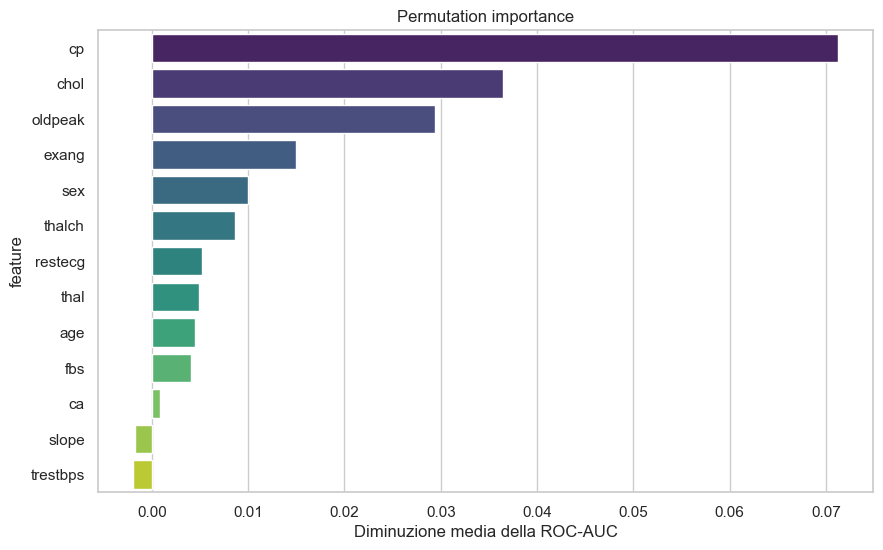

In [10]:
permutation = permutation_importance(
    final_model, X_test, y_test, n_repeats=20, random_state=RANDOM_STATE, scoring="roc_auc"
)
importance_df = pd.DataFrame(
    {
        "feature": X_test.columns,
        "importance_mean": permutation.importances_mean,
        "importance_std": permutation.importances_std,
    }
).sort_values("importance_mean", ascending=False)
display(importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x="importance_mean", y="feature", palette="viridis")
plt.title("Permutation importance")
plt.xlabel("Diminuzione media della ROC-AUC")
plt.show()

In [11]:
log_preprocessor = interpretability_model.named_steps["preprocessor"]
log_model = interpretability_model.named_steps["model"]
encoded_feature_names = log_preprocessor.get_feature_names_out()

def map_original_feature(encoded_name: str) -> str:
    clean_name = encoded_name.split("__", 1)[1]
    if clean_name in numeric_features:
        return clean_name
    if clean_name.startswith("cp_"):
        return "cp"
    if clean_name.startswith("restecg_"):
        return "restecg"
    if clean_name.startswith("slope_"):
        return "slope"
    if clean_name.startswith("thal_"):
        return "thal"
    return clean_name

logistic_coef_df = pd.DataFrame(
    {"encoded_feature": encoded_feature_names, "coefficient": log_model.coef_[0]}
)
logistic_coef_df["abs_coefficient"] = logistic_coef_df["coefficient"].abs()
logistic_coef_df["original_feature"] = logistic_coef_df["encoded_feature"].apply(map_original_feature)

aggregated_coef_df = (
    logistic_coef_df.groupby("original_feature", as_index=False)["abs_coefficient"]
    .sum()
    .sort_values("abs_coefficient", ascending=False)
)

display(logistic_coef_df.sort_values("coefficient", ascending=False).head(10))
display(logistic_coef_df.sort_values("coefficient", ascending=True).head(10))
display(aggregated_coef_df)

,encoded_feature,coefficient,abs_coefficient,original_feature
9,cat__cp_asymptomatic,0.802349,0.802349,cp
6,num__exang,0.485961,0.485961,exang
7,num__oldpeak,0.458287,0.458287,oldpeak
1,num__sex,0.446383,0.446383,sex
8,num__ca,0.440768,0.440768,ca
17,cat__slope_flat,0.355649,0.355649,slope
0,num__age,0.262877,0.262877,age
21,cat__thal_reversable defect,0.249121,0.249121,thal
15,cat__restecg_st-t abnormality,0.140019,0.140019,restecg
4,num__fbs,0.122318,0.122318,fbs


,encoded_feature,coefficient,abs_coefficient,original_feature
10,cat__cp_atypical angina,-0.601069,0.601069,cp
3,num__chol,-0.405561,0.405561,chol
5,num__thalch,-0.290924,0.290924,thalch
20,cat__thal_normal,-0.267484,0.267484,thal
18,cat__slope_upsloping,-0.235441,0.235441,slope
11,cat__cp_non-anginal,-0.143095,0.143095,cp
16,cat__slope_downsloping,-0.123771,0.123771,slope
14,cat__restecg_normal,-0.112879,0.112879,restecg
12,cat__cp_typical angina,-0.061748,0.061748,cp
13,cat__restecg_lv hypertrophy,-0.030703,0.030703,restecg


,original_feature,abs_coefficient
3,cp,1.608260
9,slope,0.714862
10,thal,0.531406
4,exang,0.485961
6,oldpeak,0.458287
8,sex,0.446383
1,ca,0.440768
2,chol,0.405561
11,thalch,0.290924
7,restecg,0.283600


## Deployment e report finale

Salviamo un bundle con il modello finale, il modello interpretabile, la soglia scelta e i metadati utili.

In [12]:
reference_summary = {
    "numeric_medians": X_train[numeric_features].median(numeric_only=True).to_dict(),
    "categorical_modes": {col: X_train[col].mode(dropna=True).iloc[0] for col in categorical_features},
}

model_bundle = {
    "model": final_model,
    "interpretability_model": interpretability_model,
    "threshold": optimal_threshold,
    "feature_columns": feature_columns,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "global_feature_importance": importance_df.to_dict(orient="records"),
    "reference_summary": reference_summary,
}

model_path = ARTIFACTS_DIR / "heart_disease_risk_bundle.joblib"
joblib.dump(model_bundle, model_path)
print(model_path.resolve())

def evaluation_cardiovascular_risk(patient_date):
    patient_df = pd.DataFrame([patient_date], columns=feature_columns)
    risk_probability = final_model.predict_proba(patient_df)[0, 1]
    predicted_label = int(risk_probability >= optimal_threshold)

    transformed_patient = log_preprocessor.transform(patient_df)
    if hasattr(transformed_patient, "toarray"):
        transformed_patient = transformed_patient.toarray()

    contributions = transformed_patient[0] * log_model.coef_[0]
    contribution_df = pd.DataFrame(
        {"encoded_feature": encoded_feature_names, "contribution": contributions}
    )
    contribution_df["original_feature"] = contribution_df["encoded_feature"].apply(map_original_feature)
    grouped = contribution_df.groupby("original_feature", as_index=False)["contribution"].sum()
    grouped = grouped.sort_values("contribution", ascending=False)

    return {
        "risk_probability": round(float(risk_probability), 4),
        "decision_threshold": optimal_threshold,
        "predicted_label": predicted_label,
        "risk_label": "High cardiovascular risk" if predicted_label == 1 else "Low cardiovascular risk",
        "main_risk_factors": grouped.head(5).to_dict(orient="records"),
        "main_protective_factors": grouped.sort_values("contribution").head(3).to_dict(orient="records"),
    }

example_patient = X_test.iloc[0].to_dict()
deployment_example = evaluation_cardiovascular_risk(example_patient)
deployment_example

C:\Users\samue\Desktop\Machine_Learning_exercises\artifacts\heart_disease_risk_bundle.joblib


{'risk_probability': 0.445,
 'decision_threshold': 0.53,
 'predicted_label': 0,
 'risk_label': 'Low cardiovascular risk',
 'main_risk_factors': [{'original_feature': 'cp',
   'contribution': 0.8023487991552204},
  {'original_feature': 'slope', 'contribution': 0.35564946279801546},
  {'original_feature': 'sex', 'contribution': 0.23432483413682018},
  {'original_feature': 'trestbps', 'contribution': -0.007088925801614115},
  {'original_feature': 'chol', 'contribution': -0.016826610890847644}],
 'main_protective_factors': [{'original_feature': 'exang',
   'contribution': -0.37315793816638115},
  {'original_feature': 'thalch', 'contribution': -0.3720961139323393},
  {'original_feature': 'oldpeak', 'contribution': -0.3702422463761647}]}

In [13]:
final_summary = pd.DataFrame(
    [
        {
            "question": "Accuracy > 85%?",
            "answer": "Si",
            "evidence": f"RandomForest tuned con soglia {optimal_threshold:.2f}: accuracy = {final_metrics_optimized['accuracy']:.4f}",
        },
        {
            "question": "Recall > 0.90?",
            "answer": "Si",
            "evidence": f"RandomForest tuned con soglia {optimal_threshold:.2f}: recall = {final_metrics_optimized['recall']:.4f}",
        },
        {
            "question": "Feature piu' predittive?",
            "answer": "cp, oldpeak, exang, sex, thalch, thal, ca",
            "evidence": "Confermate da permutation importance e coefficienti aggregati della Logistic Regression",
        },
    ]
)
display(final_summary)

print("Classification report - modello finale con soglia ottimizzata")
print(classification_report(y_test, final_pred_optimized))

report_path = ROOT / "03_classificazione_malattie_report.md"
report_text = f"""# Report - Classificazione malattie cardiovascolari

## Risposte
- Accuracy > 85%: SI. Accuracy = {final_metrics_optimized['accuracy']:.4f}
- Recall > 0.90: SI. Recall = {final_metrics_optimized['recall']:.4f}
- AUC-ROC = {final_metrics_optimized['roc_auc']:.4f}
- F1-score = {final_metrics_optimized['f1']:.4f}

## Parametri piu' predittivi
cp, oldpeak, exang, sex, thalch, thal, ca.

## Limiti
- nessuna validazione esterna
- nessuna calibrazione delle probabilita'
- explainability locale semplificata
- tuning contenuto per mantenere il notebook didattico
"""
report_path.write_text(report_text, encoding="utf-8")
print(report_path.resolve())

,question,answer,evidence
0,Accuracy > 85%?,Si,RandomForest tuned con soglia 0.53: accuracy =...
1,Recall > 0.90?,Si,RandomForest tuned con soglia 0.53: recall = 0...
2,Feature piu' predittive?,"cp, oldpeak, exang, sex, thalch, thal, ca",Confermate da permutation importance e coeffic...


Classification report - modello finale con soglia ottimizzata
              precision    recall  f1-score   support

           0       0.88      0.82      0.85        82
           1       0.86      0.91      0.89       102

    accuracy                           0.87       184
   macro avg       0.87      0.86      0.87       184
weighted avg       0.87      0.87      0.87       184

C:\Users\samue\Desktop\Machine_Learning_exercises\03_classificazione_malattie_report.md
